# Project Acknowledgment & Contributions

Source Code:

This project is based on publicly available code from the GitHub repository: serengil/tensorflow-101 by Sefik Ilkin Serengil.

License:

The original code is shared under the MIT License, and full credit goes to the original author.

Link:
https://github.com/serengil/tensorflow-101/blob/master/python/Race-Ethnicity-Prediction-Batch.ipynb


My Contributions:

I have customized and extended the original code to develop a deep learning model for Ethnicity Classification with the following enhancements:


*   Adapted the dataset to use a custom dataset focused on Malaysian ethnicities (Malay, Indian, Chinese)
*   Applied data augmentation techniques to improve generalization.
*   Optimized random sampling to avoid duplicates samples in mini batching
*   Included other parameters to improved model trainig which include different dropout rate, L2 regularization and learning rate reducer.
*   Added performance metrics including precision, recall, F1-score.



In [1]:
## 1. Setup and Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import cv2
import os
import random
import pickle
import time
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Activation, Dropout, Flatten, Input, Convolution2D, ZeroPadding2D, MaxPooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.regularizers import l2
import albumentations as A

os.environ["CUDA_VISIBLE_DEVICES"] = "6"
tqdm.pandas()

import warnings
warnings.filterwarnings('ignore')

# Dataset Preparation

## Loads image data from pickel and preprocessing

* Preprocessed images are saved as .pkl (pickle) files to avoid repeating the preprocessing step, significantly reducing loading time during training.

* Converted to RGB to ensure consistent color format across the dataset.

* Resized to 224 × 224 pixels, which is the standard input size required by the VGGFace model.

* Converted to NumPy arrays, which allows them to be processed by machine

* Applied normalization by scaling pixel values to the range [0, 1] (dividing by 255) to helps the model train faster and improves convergence.

## Label Encoding

* Identifies all unique ethnic categories in training set.

* Replaces each unique ethnicity label ("Malay", "Chinese", "Indian") with a unique integer starting from 1.

In [2]:
## 2. Data Loading and Preprocessing
with open('/content/drive/MyDrive/Training/Dataset_080625/train_df_preprocessed.pkl', 'rb') as f:
    train_df = pickle.load(f)
with open('/content/drive/MyDrive/Training/Dataset_080625/test_df_preprocessed.pkl', 'rb') as f:
    test_df = pickle.load(f)

train_features = np.array([train_df['pixels'].values[i] for i in range(train_df.shape[0])])
train_features = train_features.reshape(train_features.shape[0], 224, 224, 3) / 255.0
test_features = np.array([test_df['pixels'].values[i] for i in range(test_df.shape[0])])
test_features = test_features.reshape(test_features.shape[0], 224, 224, 3) / 255.0

train_label = train_df[['ethnicity']]
test_label = test_df[['ethnicity']]
races = train_df['ethnicity'].unique()

for j, race in enumerate(races):
    current_race = races[j]
    print(f"Replacing {race} with {j+1}")
    train_label['ethnicity'] = train_label['ethnicity'].replace(race, str(j+1))
    test_label['ethnicity'] = test_label['ethnicity'].replace(race, str(j+1))

train_label = train_label.astype({'ethnicity': 'int32'})
test_label = test_label.astype({'ethnicity': 'int32'})

train_target = pd.get_dummies(train_label['ethnicity'], prefix='ethnicity')
test_target = pd.get_dummies(test_label['ethnicity'], prefix='ethnicity')

train_x, val_x, train_y, val_y = train_test_split(train_features, train_target.values, test_size=0.12, random_state=17)

print(f"Training samples: {train_x.shape[0]}")
print(f"Validation samples: {val_x.shape[0]}")
print(f"Test samples: {test_features.shape[0]}")

Replacing Indian with 1
Replacing Malay with 2
Replacing Chinese with 3
Training samples: 971
Validation samples: 133
Test samples: 276


# Data Augmentation

To enhance the robustness and generalization capability of the ethnicity classification model, two comprehensive data augmentation pipelines were designed using the Albumentations library. These pipelines simulate real-world image variability and help the model become more resilient to noise, distortions, and inconsistencies often found in real-life datasets.

Pipeline Overview:

aug_pipeline_1 and aug_pipeline_2 are composed of similar transformations with slightly different rotation limits, intended to provide subtle variation between training sessions.

The augmentations include:

* Horizontal Flip: Flips the image horizontally with a probability of 0.5 to simulate different head orientations.

* Rotate: Applies random rotation within a limited angle range (±15° in aug_pipeline_1, ±10° in aug_pipeline_2).

* Random Brightness and Contrast Adjustment: Randomly adjusts brightness and contrast to handle variations in lighting conditions.

* ShiftScaleRotate: Applies small shifts, zooms, and rotations, introducing spatial distortions that improve model invariance to viewpoint changes.

* Gaussian Blur: Slightly blurs the image to simulate lower-resolution images or minor focus issues.

* Random Crop and Resize: Randomly crops a smaller section of the image and resizes it back to the input size (224x224). This helps the model focus on different facial regions and improves spatial flexibility.

* Resize: Ensures all images are consistently resized to 224x224 pixels, suitable for the input requirements of most CNN architectures like VGGFace.

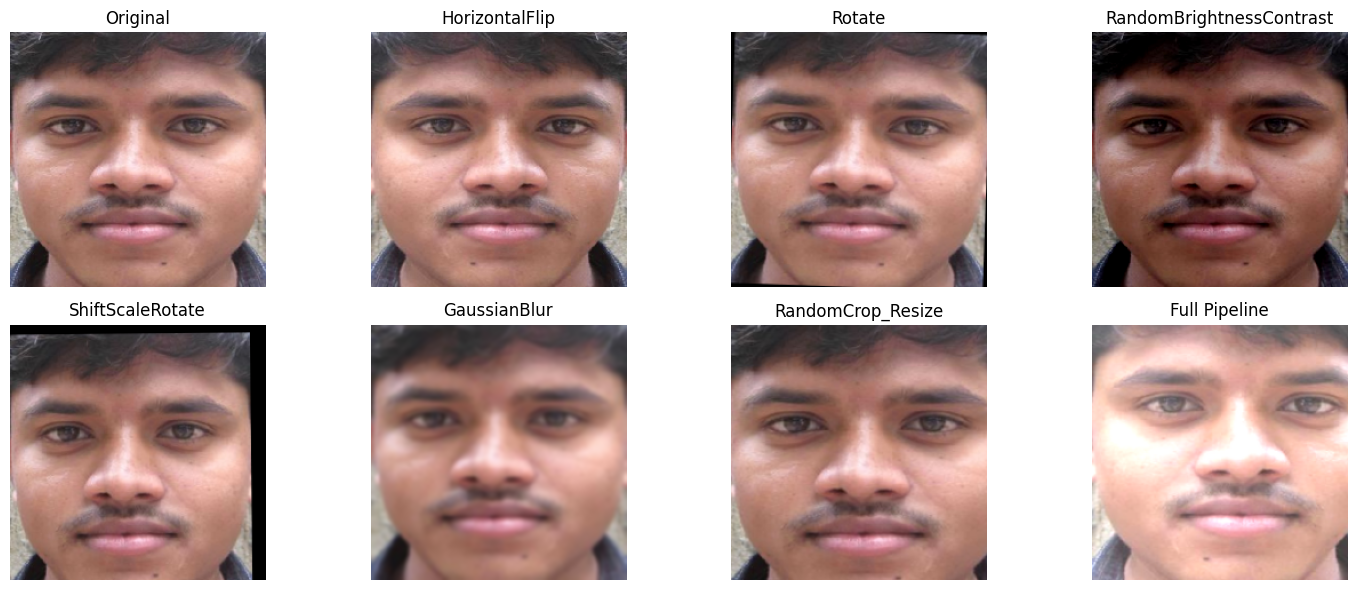

In [3]:
## 3. Data Augmentation Pipelines
aug_pipeline_1 = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=10, p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
    A.RandomCrop(height=200, width=200, p=0.2),
    A.Resize(height=224, width=224, always_apply=True),
], p=1.0)

aug_pipeline_2 = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=10, p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
    A.RandomCrop(height=200, width=200, p=0.2),
    A.Resize(height=224, width=224, always_apply=True),
], p=1.0)

sample_image = train_x[0].copy()
augmentations = {
    "HorizontalFlip": A.Compose([A.HorizontalFlip(p=1.0)]),
    "Rotate": A.Compose([A.Rotate(limit=15, p=1.0)]),
    "RandomBrightnessContrast": A.Compose([A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0)]),
    "ShiftScaleRotate": A.Compose([A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=10, p=1.0)]),
    "GaussianBlur": A.Compose([A.GaussianBlur(blur_limit=(3, 7), p=1.0)]),
    "RandomCrop_Resize": A.Compose([A.RandomCrop(height=200, width=200, p=1.0), A.Resize(height=224, width=224)]),
    "Full Pipeline": aug_pipeline_1
}

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.flatten()
axes[0].imshow(sample_image)
axes[0].set_title("Original")
axes[0].axis('off')
for idx, (aug_name, aug_pipeline) in enumerate(augmentations.items(), 1):
    augmented_image = aug_pipeline(image=sample_image)['image']
    axes[idx].imshow(augmented_image)
    axes[idx].set_title(aug_name)
    axes[idx].axis('off')
plt.tight_layout()
plt.show()

# Model Construction

In [4]:
## 4. Model Definitions
def build_vgg_face_model(num_classes=3, reg_params=None, dropout_rate=0.5):
    model = Sequential()
    model.add(ZeroPadding2D((1,1), input_shape=(224,224,3)))
    model.add(Convolution2D(64, (3,3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(64, (3,3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3,3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3,3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3,3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3,3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3,3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3,3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3,3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3,3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3,3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3,3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3,3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    reg = reg_params if reg_params else l2(0.01)
    model.add(Convolution2D(4096, (7,7), activation='relu', kernel_regularizer=reg))
    model.add(Dropout(dropout_rate))
    model.add(Convolution2D(4096, (1,1), activation='relu', kernel_regularizer=reg))
    model.add(Dropout(dropout_rate))
    model.add(Convolution2D(2622, (1,1), kernel_regularizer=reg))
    model.add(Flatten())
    model.add(Activation('softmax'))

    model.load_weights('/content/drive/MyDrive/Colab Notebooks/Ethnic Classification/vgg_face_weights.h5')

    for layer in model.layers[:-6]:
        layer.trainable = False

    model_input = model.layers[0].input
    base_model_output = Convolution2D(num_classes, (1,1), name='predictions', kernel_regularizer=reg)(model.layers[-4].output)
    base_model_output = Flatten()(base_model_output)
    base_model_output = Dropout(dropout_rate)(base_model_output)
    base_model_output = Activation('softmax')(base_model_output)

    race_model = Model(inputs=model_input, outputs=base_model_output)
    return race_model

In [5]:
## 5. Training Function
def train_model(model, model_name, aug_pipeline=None, lr_params=None):
    batch_size = 256  # Increased batch size for stability
    epochs = 1000
    patience = 30

    checkpointer = ModelCheckpoint(
        filepath=f'/content/drive/MyDrive/Training/Dataset_080625/model_{model_name}.h5',
        monitor='val_loss',
        verbose=1,
        save_best_only=True,
        mode='auto'
    )

    callbacks = [checkpointer]
    if lr_params:
        lr_reducer = ReduceLROnPlateau(
            monitor='val_loss',
            factor=lr_params['factor'],
            patience=lr_params['patience'],
            min_lr=lr_params['min_lr'],
            verbose=1
        )
        callbacks.append(lr_reducer)

    val_scores, train_scores, val_acc_scores, train_acc_scores = [], [], [], []
    last_improvement = 0
    best_iteration = 0
    loss = 1e6

    print(f"\n=== Training {model_name} ===")
    print(f"Batch Size: {batch_size} | Max Epochs: {epochs} | Patience: {patience}\n")

    for i in range(epochs):
        print(f"Epoch {i+1:04d}/{epochs} | ", end="")
        ix_train = np.random.choice(train_x.shape[0], size=batch_size, replace=False)
        batch_x = train_x[ix_train].copy()
        batch_y = train_y[ix_train]

        if aug_pipeline:
            for j in range(batch_x.shape[0]):
                batch_x[j] = aug_pipeline(image=batch_x[j])['image']

        # Adjust validation batch size to be at most the size of the validation set
        val_batch_size = min(batch_size, val_x.shape[0])
        ix_val = np.random.choice(val_x.shape[0], size=val_batch_size, replace=False)
        batch_val_x = val_x[ix_val].copy()
        batch_val_y = val_y[ix_val]

        score = model.fit(
            batch_x, batch_y,
            epochs=1,
            validation_data=(batch_val_x, batch_val_y),
            callbacks=callbacks,
            verbose=1
        )

        val_loss = score.history['val_loss'][0]
        train_loss = score.history['loss'][0]
        val_acc = score.history['val_accuracy'][0]
        train_acc = score.history['accuracy'][0]

        val_scores.append(val_loss)
        train_scores.append(train_loss)
        val_acc_scores.append(val_acc)
        train_acc_scores.append(train_acc)

        if val_loss < loss:
            loss = val_loss
            last_improvement = 0
            best_iteration = i
        else:
            last_improvement += 1
            print(f"Try to decrease val loss for {patience - last_improvement} epochs more")

        print(f"Best validation loss so far: {loss:.4f} at epoch {best_iteration + 1}")

        if last_improvement == patience:
            print(f"No loss decrease in validation for {patience} epochs. Early stopped.")
            break

    return {
        'val_scores': val_scores,
        'train_scores': train_scores,
        'val_acc_scores': val_acc_scores,
        'train_acc_scores': train_acc_scores,
        'best_iteration': best_iteration,
        'best_val_loss': loss
    }


=== Training baseline ===
Batch Size: 256 | Max Epochs: 1000 | Patience: 30

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4987 - loss: 4.1005
Epoch 1: val_loss improved from inf to 1.57228, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_baseline.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.5049 - loss: 3.9967 - val_accuracy: 0.8421 - val_loss: 1.5723
Best validation loss so far: 1.5723 at epoch 1
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6406 - loss: 1.5561
Epoch 1: val_loss improved from 1.57228 to 1.18470, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_baseline.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.6423 - loss: 1.5486 - val_accuracy: 0.8271 - val_loss: 1.1847
Best validation loss so far: 1.1847 at epoch 2
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6291 - loss: 1.3543
Epoch 1: val_loss improved from 1.18470 to 1.08119, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_baseline.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6308 - loss: 1.3514 - val_accuracy: 0.8120 - val_loss: 1.0812
Best validation loss so far: 1.0812 at epoch 3
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7108 - loss: 1.2123
Epoch 1: val_loss improved from 1.08119 to 0.95553, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_baseline.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.7095 - loss: 1.2094 - val_accuracy: 0.8496 - val_loss: 0.9555
Best validation loss so far: 0.9555 at epoch 4
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6752 - loss: 1.1707
Epoch 1: val_loss improved from 0.95553 to 0.91071, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_baseline.h5


...

8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7333 - loss: 0.9168 - val_accuracy: 0.9098 - val_loss: 0.7121
Best validation loss so far: 0.7121 at epoch 51
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6715 - loss: 0.9441
Epoch 1: val_loss did not improve from 0.71206
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6733 - loss: 0.9456 - val_accuracy: 0.9173 - val_loss: 0.7130
Try to decrease val loss for 29 epochs more
Best validation loss so far: 0.7121 at epoch 51
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7143 - loss: 0.8913
Epoch 1: val_loss did not improve from 0.71206
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.7153 - loss: 0.8913 - val_accuracy: 0.8872 - val_loss: 0.7397
Try to decrease val loss for 28 epochs more
Best validation loss so far: 0.7121 at epoch 51
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6132 - loss: 1.0050
Epoch 1: val_loss did not improve from 0.71206
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6162 - loss: 1.0072 - val_a

8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7431 - loss: 0.8632 - val_accuracy: 0.9023 - val_loss: 0.7111
Best validation loss so far: 0.7111 at epoch 61
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7500 - loss: 0.8797
Epoch 1: val_loss did not improve from 0.71109
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.7517 - loss: 0.8782 - val_accuracy: 0.9023 - val_loss: 0.7261
Try to decrease val loss for 29 epochs more
Best validation loss so far: 0.7111 at epoch 61
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6883 - loss: 0.8708
Epoch 1: val_loss did not improve from 0.71109
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6900 - loss: 0.8725 - val_accuracy: 0.8872 - val_loss: 0.7220
Try to decrease val loss for 28 epochs more
Best validation loss so far: 0.7111 at epoch 61
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6694 - loss: 0.9273
Epoch 1: val_loss did not improve from 0.71109
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6723 - loss: 0.9250 - val_a

8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7469 - loss: 0.8542 - val_accuracy: 0.8872 - val_loss: 0.7108
Best validation loss so far: 0.7108 at epoch 73
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6773 - loss: 0.9670
Epoch 1: val_loss improved from 0.71077 to 0.70985, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_baseline.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.6784 - loss: 0.9616 - val_accuracy: 0.8872 - val_loss: 0.7099
Best validation loss so far: 0.7099 at epoch 74
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7147 - loss: 0.9046
Epoch 1: val_loss improved from 0.70985 to 0.69045, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_baseline.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7156 - loss: 0.9043 - val_accuracy: 0.9173 - val_loss: 0.6905
Best validation loss so far: 0.6905 at epoch 75
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7008 - loss: 0.8647
Epoch 1: val_loss did not improve from 0.69045
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.7080 - loss: 0.8621 - val_accuracy: 0.8947 - val_loss: 0.7019
Try to decrease val loss for 29 epochs more
Best validation loss so far: 0.6905 at epoch 75
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6578 - loss: 0.9740
Epoch 1: val_loss did not improve from 0.69045
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.6620 - loss: 0.9678 - val_accuracy: 0.9398 - val_loss: 0.6991
Try to decrease val loss for 28 epochs more
Best validation loss so far: 0.6905 at epoch 75
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6741 - loss: 0.9587
Epoch 1: val_loss did not improve from 0.69045
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6760 - loss: 0.9559 - val_a

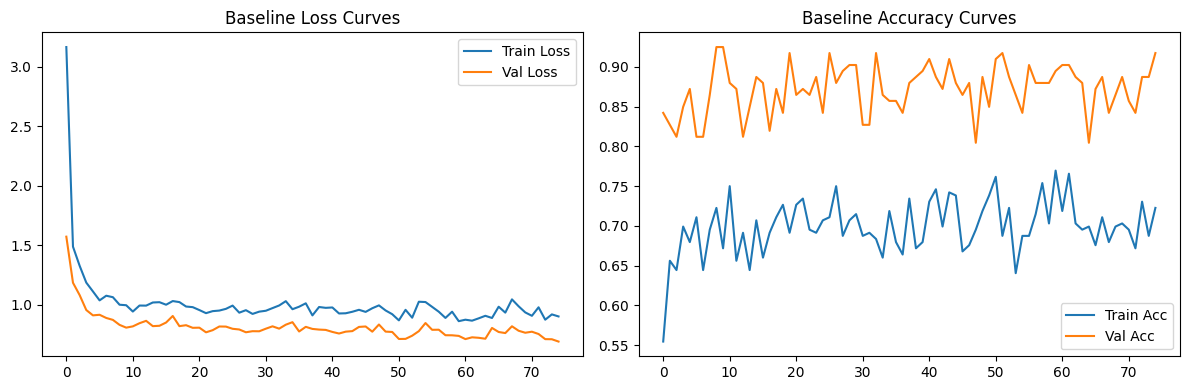

In [6]:
## 6. Experiment 1: Baseline Model
baseline_model = build_vgg_face_model(num_classes=3, reg_params=None, dropout_rate=0.5)
baseline_model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, weight_decay=1e-4),
    metrics=['accuracy']
)

baseline_results = train_model(baseline_model, 'baseline')

baseline_test_perf = baseline_model.evaluate(test_features, test_target.values, verbose=1)
baseline_val_perf = baseline_model.evaluate(val_x, val_y, verbose=1)
print(f"\nBaseline Model Robustness Check: {abs(baseline_val_perf[0] - baseline_test_perf[0]) < 0.05}")

test_predictions = baseline_model.predict(test_features, verbose=0)
test_prediction_classes = [races[np.argmax(pred)] for pred in test_predictions]
test_actual_classes = [races[np.argmax(y)] for y in test_target.values]
print("\nBaseline Test Classification Report:")
print(classification_report(test_actual_classes, test_prediction_classes, target_names=races))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(baseline_results['train_scores'][:baseline_results['best_iteration']+1], label='Train Loss')
plt.plot(baseline_results['val_scores'][:baseline_results['best_iteration']+1], label='Val Loss')
plt.title('Baseline Loss Curves')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(baseline_results['train_acc_scores'][:baseline_results['best_iteration']+1], label='Train Acc')
plt.plot(baseline_results['val_acc_scores'][:baseline_results['best_iteration']+1], label='Val Acc')
plt.title('Baseline Accuracy Curves')
plt.legend()
plt.tight_layout()
plt.show()


=== Training finetuned1 ===
Batch Size: 256 | Max Epochs: 1000 | Patience: 30

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5332 - loss: 1.3240
Epoch 1: val_loss improved from inf to 0.69157, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_finetuned1.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.5438 - loss: 1.3055 - val_accuracy: 0.8722 - val_loss: 0.6916 - learning_rate: 0.0010
Best validation loss so far: 0.6916 at epoch 1
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7894 - loss: 0.7446
Epoch 1: val_loss improved from 0.69157 to 0.67125, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_finetuned1.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.7876 - loss: 0.7425 - val_accuracy: 0.7820 - val_loss: 0.6713 - learning_rate: 0.0010
Best validation loss so far: 0.6713 at epoch 2
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7539 - loss: 0.7299
Epoch 1: val_loss improved from 0.67125 to 0.51893, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_finetuned1.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.7556 - loss: 0.7258 - val_accuracy: 0.8947 - val_loss: 0.5189 - learning_rate: 0.0010
Best validation loss so far: 0.5189 at epoch 3
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7740 - loss: 0.7833
Epoch 1: val_loss improved from 0.51893 to 0.50802, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_finetuned1.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.7726 - loss: 0.7788 - val_accuracy: 0.8947 - val_loss: 0.5080 - learning_rate: 0.0010
Best validation loss so far: 0.5080 at epoch 4
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8278 - loss: 0.6590
Epoch 1: val_loss improved from 0.50802 to 0.48569, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_finetuned1.h5


...

8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.8486 - loss: 0.5185 - val_accuracy: 0.9098 - val_loss: 0.4800 - learning_rate: 0.0010
Best validation loss so far: 0.4800 at epoch 7
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8290 - loss: 0.6267
Epoch 1: val_loss did not improve from 0.48000
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8315 - loss: 0.6202 - val_accuracy: 0.9098 - val_loss: 0.5167 - learning_rate: 0.0010
Try to decrease val loss for 29 epochs more
Best validation loss so far: 0.4800 at epoch 7
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8448 - loss: 0.6181
Epoch 1: val_loss did not improve from 0.48000
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.8469 - loss: 0.6153 - val_accuracy: 0.9023 - val_loss: 0.4850 - learning_rate: 0.0010
Try to decrease val loss for 28 epochs more
Best validation loss so far: 0.4800 at epoch 7
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7634 - loss: 0.6043
Epoch 1: val_loss improved from 0.48000 to 0.45560, savi

8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7636 - loss: 0.6074 - val_accuracy: 0.9173 - val_loss: 0.4556 - learning_rate: 0.0010
Best validation loss so far: 0.4556 at epoch 10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8589 - loss: 0.4968
Epoch 1: val_loss did not improve from 0.45560
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8576 - loss: 0.4985 - val_accuracy: 0.8496 - val_loss: 0.5277 - learning_rate: 0.0010
Try to decrease val loss for 29 epochs more
Best validation loss so far: 0.4556 at epoch 10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8265 - loss: 0.6295
Epoch 1: val_loss did not improve from 0.45560
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.8262 - loss: 0.6277 - val_accuracy: 0.8872 - val_loss: 0.4866 - learning_rate: 0.0010
Try to decrease val loss for 28 epochs more
Best validation loss so far: 0.4556 at epoch 10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8470 - loss: 0.5971
Epoch 1: val_loss did not improve from 0.45560
8/8 ━━

8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.8039 - loss: 0.5930 - val_accuracy: 0.9098 - val_loss: 0.4355 - learning_rate: 0.0010
Best validation loss so far: 0.4355 at epoch 39
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8388 - loss: 0.6160
Epoch 1: val_loss did not improve from 0.43550
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8402 - loss: 0.6111 - val_accuracy: 0.9098 - val_loss: 0.4525 - learning_rate: 0.0010
Try to decrease val loss for 29 epochs more
Best validation loss so far: 0.4355 at epoch 39
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8417 - loss: 0.5432
Epoch 1: val_loss did not improve from 0.43550
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8424 - loss: 0.5405 - val_accuracy: 0.8947 - val_loss: 0.4766 - learning_rate: 0.0010
Try to decrease val loss for 28 epochs more
Best validation loss so far: 0.4355 at epoch 39
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8833 - loss: 0.4907
Epoch 1: val_loss did not improve from 0.43550
8/8 ━━

8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.8684 - loss: 0.4751 - val_accuracy: 0.9098 - val_loss: 0.4290 - learning_rate: 0.0010
Best validation loss so far: 0.4290 at epoch 68
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8189 - loss: 0.4875
Epoch 1: val_loss did not improve from 0.42895
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8195 - loss: 0.4858 - val_accuracy: 0.9098 - val_loss: 0.4534 - learning_rate: 0.0010
Try to decrease val loss for 29 epochs more
Best validation loss so far: 0.4290 at epoch 68
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8731 - loss: 0.4345
Epoch 1: val_loss improved from 0.42895 to 0.41314, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_finetuned1.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.8712 - loss: 0.4376 - val_accuracy: 0.9173 - val_loss: 0.4131 - learning_rate: 0.0010
Best validation loss so far: 0.4131 at epoch 70
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8708 - loss: 0.5540
Epoch 1: val_loss did not improve from 0.41314
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8699 - loss: 0.5518 - val_accuracy: 0.9023 - val_loss: 0.4691 - learning_rate: 0.0010
Try to decrease val loss for 29 epochs more
Best validation loss so far: 0.4131 at epoch 70
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8421 - loss: 0.5065
Epoch 1: val_loss did not improve from 0.41314
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.8427 - loss: 0.5046 - val_accuracy: 0.9098 - val_loss: 0.4146 - learning_rate: 0.0010
Try to decrease val loss for 28 epochs more
Best validation loss so far: 0.4131 at epoch 70
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8501 - loss: 0.5166
Epoch 1: val_loss did not improve from 0.41314
8/8 ━━

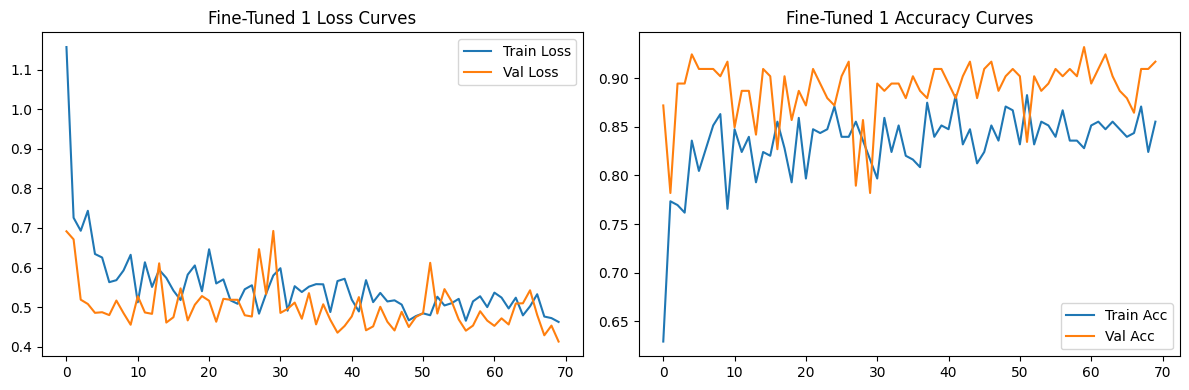

In [7]:
## 7. Experiment 2: Fine-Tuned Model 1
ft1_model = build_vgg_face_model(num_classes=3, reg_params=l2(0.001), dropout_rate=0.3)
ft1_model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, weight_decay=1e-4),
    metrics=['accuracy']
)

lr_params_1 = {'factor': 0.5, 'patience': 10, 'min_lr': 1e-6}
ft1_results = train_model(ft1_model, 'finetuned1', aug_pipeline=aug_pipeline_1, lr_params=lr_params_1)

ft1_test_perf = ft1_model.evaluate(test_features, test_target.values, verbose=1)
ft1_val_perf = ft1_model.evaluate(val_x, val_y, verbose=1)
print(f"\nFine-Tuned 1 Model Robustness Check: {abs(ft1_val_perf[0] - ft1_test_perf[0]) < 0.05}")

test_predictions = ft1_model.predict(test_features, verbose=0)
test_prediction_classes = [races[np.argmax(pred)] for pred in test_predictions]
test_actual_classes = [races[np.argmax(y)] for y in test_target.values]
print("\nFine-Tuned 1 Test Classification Report:")
print(classification_report(test_actual_classes, test_prediction_classes, target_names=races))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(ft1_results['train_scores'][:ft1_results['best_iteration']+1], label='Train Loss')
plt.plot(ft1_results['val_scores'][:ft1_results['best_iteration']+1], label='Val Loss')
plt.title('Fine-Tuned 1 Loss Curves')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(ft1_results['train_acc_scores'][:ft1_results['best_iteration']+1], label='Train Acc')
plt.plot(ft1_results['val_acc_scores'][:ft1_results['best_iteration']+1], label='Val Acc')
plt.title('Fine-Tuned 1 Accuracy Curves')
plt.legend()
plt.tight_layout()
plt.show()


=== Training finetuned2 ===
Batch Size: 256 | Max Epochs: 1000 | Patience: 30

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6103 - loss: 1.0319
Epoch 1: val_loss improved from inf to 0.53967, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_finetuned2.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.6167 - loss: 1.0206 - val_accuracy: 0.8947 - val_loss: 0.5397 - learning_rate: 0.0010
Best validation loss so far: 0.5397 at epoch 1
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6365 - loss: 0.6772
Epoch 1: val_loss improved from 0.53967 to 0.37975, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_finetuned2.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.6426 - loss: 0.6703 - val_accuracy: 0.8797 - val_loss: 0.3797 - learning_rate: 0.0010
Best validation loss so far: 0.3797 at epoch 2
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7943 - loss: 0.5293
Epoch 1: val_loss improved from 0.37975 to 0.34763, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_finetuned2.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.7937 - loss: 0.5281 - val_accuracy: 0.8947 - val_loss: 0.3476 - learning_rate: 0.0010
Best validation loss so far: 0.3476 at epoch 3
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7899 - loss: 0.5155
Epoch 1: val_loss improved from 0.34763 to 0.31444, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_finetuned2.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.7915 - loss: 0.5128 - val_accuracy: 0.9023 - val_loss: 0.3144 - learning_rate: 0.0010
Best validation loss so far: 0.3144 at epoch 4
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7740 - loss: 0.5869
Epoch 1: val_loss did not improve from 0.31444
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.7730 - loss: 0.5860 - val_accuracy: 0.8872 - val_loss: 0.3540 - learning_rate: 0.0010
Try to decrease val loss for 29 epochs more
Best validation loss so far: 0.3144 at epoch 4
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7783 - loss: 0.5305
Epoch 1: val_loss did not improve from 0.31444
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.7760 - loss: 0.5345 - val_accuracy: 0.8872 - val_loss: 0.3495 - learning_rate: 0.0010
Try to decrease val loss for 28 epochs more
Best validation loss so far: 0.3144 at epoch 4
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7912 - loss: 0.4629
Epoch 1: val_loss did not improve from 0.31444
8/8 ━━━━━

8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.7900 - loss: 0.4184 - val_accuracy: 0.9098 - val_loss: 0.3069 - learning_rate: 0.0010
Best validation loss so far: 0.3069 at epoch 19
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8288 - loss: 0.4085
Epoch 1: val_loss did not improve from 0.30694
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8279 - loss: 0.4127 - val_accuracy: 0.8947 - val_loss: 0.3485 - learning_rate: 0.0010
Try to decrease val loss for 29 epochs more
Best validation loss so far: 0.3069 at epoch 19
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8511 - loss: 0.4164
Epoch 1: val_loss did not improve from 0.30694
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.8494 - loss: 0.4181 - val_accuracy: 0.9023 - val_loss: 0.3718 - learning_rate: 0.0010
Try to decrease val loss for 28 epochs more
Best validation loss so far: 0.3069 at epoch 19
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8848 - loss: 0.3555
Epoch 1: val_loss did not improve from 0.30694
8/8 ━━

8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.8773 - loss: 0.3753 - val_accuracy: 0.9323 - val_loss: 0.3026 - learning_rate: 0.0010
Best validation loss so far: 0.3026 at epoch 28
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8307 - loss: 0.3718
Epoch 1: val_loss did not improve from 0.30259
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8317 - loss: 0.3784 - val_accuracy: 0.9248 - val_loss: 0.3122 - learning_rate: 0.0010
Try to decrease val loss for 29 epochs more
Best validation loss so far: 0.3026 at epoch 28
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8547 - loss: 0.4062
Epoch 1: val_loss improved from 0.30259 to 0.29059, saving model to /content/drive/MyDrive/Training/Dataset_080625/model_finetuned2.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.8518 - loss: 0.4112 - val_accuracy: 0.9248 - val_loss: 0.2906 - learning_rate: 0.0010
Best validation loss so far: 0.2906 at epoch 30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8532 - loss: 0.3738
Epoch 1: val_loss did not improve from 0.29059
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8531 - loss: 0.3715 - val_accuracy: 0.9173 - val_loss: 0.2932 - learning_rate: 0.0010
Try to decrease val loss for 29 epochs more
Best validation loss so far: 0.2906 at epoch 30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8813 - loss: 0.3385
Epoch 1: val_loss did not improve from 0.29059
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.8802 - loss: 0.3409 - val_accuracy: 0.9248 - val_loss: 0.3377 - learning_rate: 0.0010
Try to decrease val loss for 28 epochs more
Best validation loss so far: 0.2906 at epoch 30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8735 - loss: 0.3665
Epoch 1: val_loss did not improve from 0.29059
8/8 ━━

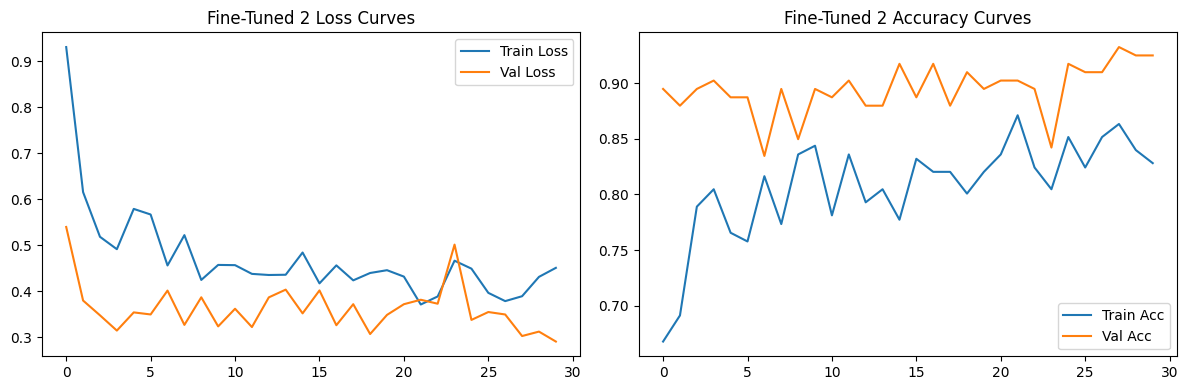

In [8]:
## 8. Experiment 3: Fine-Tuned Model 2
ft2_model = build_vgg_face_model(num_classes=3, reg_params=l2(0.0001), dropout_rate=0.35)
ft2_model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, weight_decay=1e-4),
    metrics=['accuracy']
)

lr_params_2 = {'factor': 0.5, 'patience': 10, 'min_lr': 1e-6}
ft2_results = train_model(ft2_model, 'finetuned2', aug_pipeline=aug_pipeline_2, lr_params=lr_params_2)

ft2_test_perf = ft2_model.evaluate(test_features, test_target.values, verbose=1)
ft2_val_perf = ft2_model.evaluate(val_x, val_y, verbose=1)
print(f"\nFine-Tuned 2 Model Robustness Check: {abs(ft2_val_perf[0] - ft2_test_perf[0]) < 0.05}")

test_predictions = ft2_model.predict(test_features, verbose=0)
test_prediction_classes = [races[np.argmax(pred)] for pred in test_predictions]
test_actual_classes = [races[np.argmax(y)] for y in test_target.values]
print("\nFine-Tuned 2 Test Classification Report:")
print(classification_report(test_actual_classes, test_prediction_classes, target_names=races))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(ft2_results['train_scores'][:ft2_results['best_iteration']+1], label='Train Loss')
plt.plot(ft2_results['val_scores'][:ft2_results['best_iteration']+1], label='Val Loss')
plt.title('Fine-Tuned 2 Loss Curves')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(ft2_results['train_acc_scores'][:ft2_results['best_iteration']+1], label='Train Acc')
plt.plot(ft2_results['val_acc_scores'][:ft2_results['best_iteration']+1], label='Val Acc')
plt.title('Fine-Tuned 2 Accuracy Curves')
plt.legend()
plt.tight_layout()
plt.show()


Performance Comparison Table:

          Model  Val Loss  Test Loss  Val Accuracy  Test Accuracy  \
0      Baseline    0.6905     0.7122        0.8797         0.8913   
1  Fine-Tuned 1    0.4131     0.4632        0.9098         0.8768   
2  Fine-Tuned 2    0.2906     0.3598        0.8947         0.9022   

   Robustness (Val-Test Loss < 0.05)  Loss Difference  
0                               True           0.0136  
1                               True           0.0384  
2                               True           0.0482  


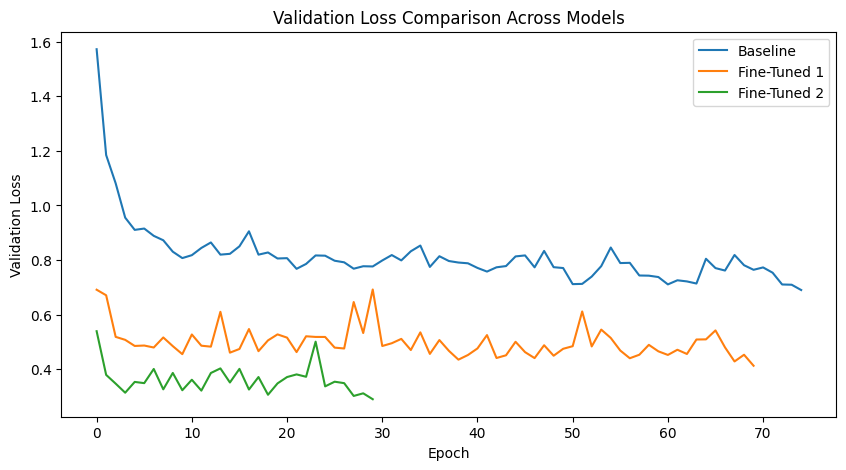

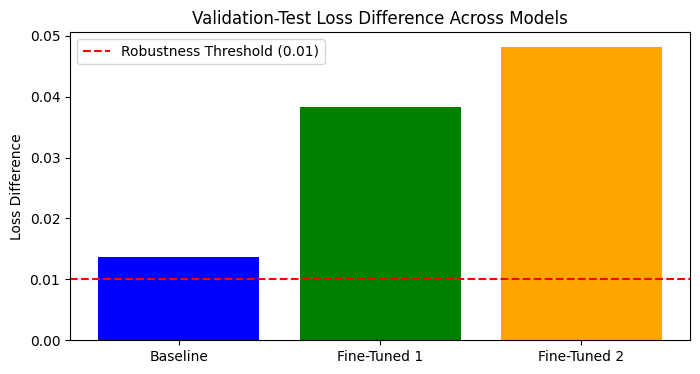

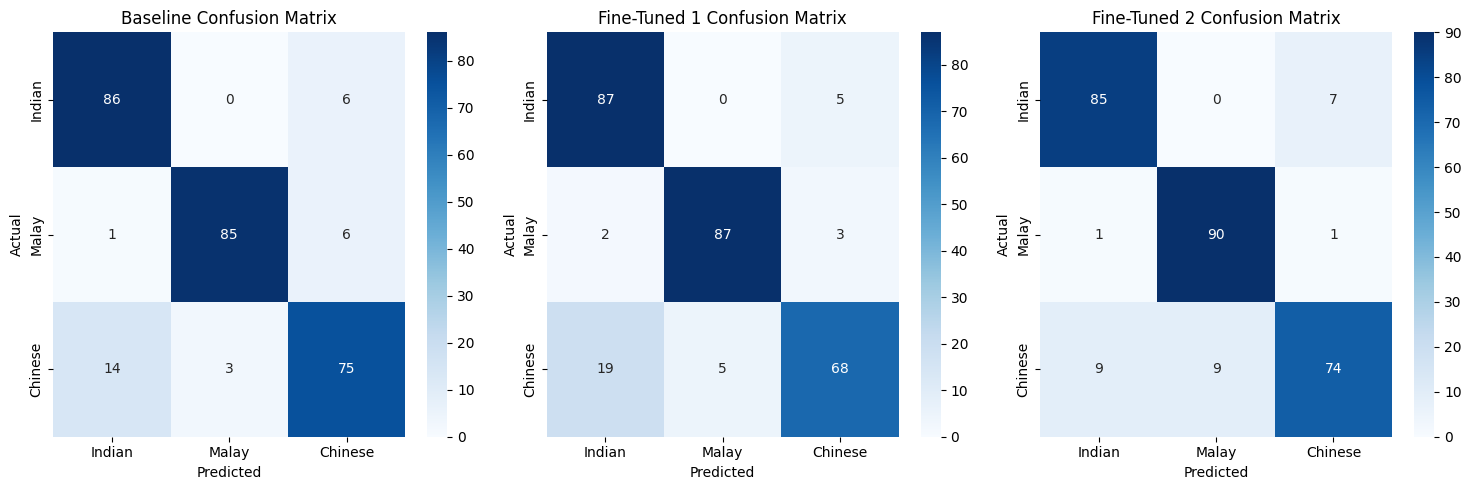

In [9]:
## 9. Results Comparison
results_summary = pd.DataFrame({
    'Model': ['Baseline', 'Fine-Tuned 1', 'Fine-Tuned 2'],
    'Val Loss': [baseline_results['best_val_loss'], ft1_results['best_val_loss'], ft2_results['best_val_loss']],
    'Test Loss': [baseline_test_perf[0], ft1_test_perf[0], ft2_test_perf[0]],
    'Val Accuracy': [baseline_val_perf[1], ft1_val_perf[1], ft2_val_perf[1]],
    'Test Accuracy': [baseline_test_perf[1], ft1_test_perf[1], ft2_test_perf[1]],
    'Robustness (Val-Test Loss < 0.05)': [
        abs(baseline_val_perf[0] - baseline_test_perf[0]) < 0.05,
        abs(ft1_val_perf[0] - ft1_test_perf[0]) < 0.05,
        abs(ft2_val_perf[0] - ft2_test_perf[0]) < 0.05
    ],
    'Loss Difference': [
        abs(baseline_val_perf[0] - baseline_test_perf[0]),
        abs(ft1_val_perf[0] - ft1_test_perf[0]),
        abs(ft2_val_perf[0] - ft2_test_perf[0])
    ]
})

print("\nPerformance Comparison Table:\n")
print(results_summary.round(4))

plt.figure(figsize=(10, 5))
plt.plot(baseline_results['val_scores'][:baseline_results['best_iteration']+1], label='Baseline')
plt.plot(ft1_results['val_scores'][:ft1_results['best_iteration']+1], label='Fine-Tuned 1')
plt.plot(ft2_results['val_scores'][:ft2_results['best_iteration']+1], label='Fine-Tuned 2')
plt.title('Validation Loss Comparison Across Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(results_summary['Model'], results_summary['Loss Difference'], color=['blue', 'green', 'orange'])
plt.title('Validation-Test Loss Difference Across Models')
plt.ylabel('Loss Difference')
plt.axhline(y=0.01, color='r', linestyle='--', label='Robustness Threshold (0.01)')
plt.legend()
plt.show()

models = [('Baseline', baseline_model), ('Fine-Tuned 1', ft1_model), ('Fine-Tuned 2', ft2_model)]
plt.figure(figsize=(15, 5))
for idx, (name, model) in enumerate(models, 1):
    preds = model.predict(test_features, verbose=0)
    pred_classes = [races[np.argmax(pred)] for pred in preds]
    actual_classes = [races[np.argmax(y)] for y in test_target.values]
    cm = confusion_matrix(actual_classes, pred_classes)
    df_cm = pd.DataFrame(cm, index=races, columns=races)
    plt.subplot(1, 3, idx)
    sn.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
plt.tight_layout()
plt.show()


Sample Predictions from Fine-Tuned 2:

Index: 251
Actual:  Malay
Predicted:  Malay


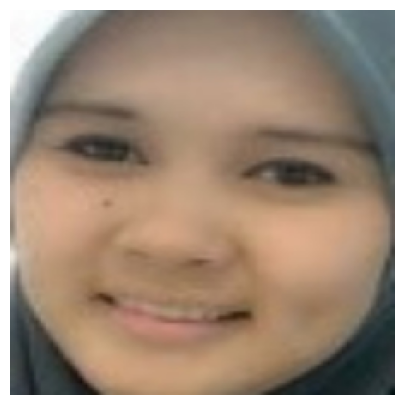

----------------------
Index: 249
Actual:  Indian
Predicted:  Indian


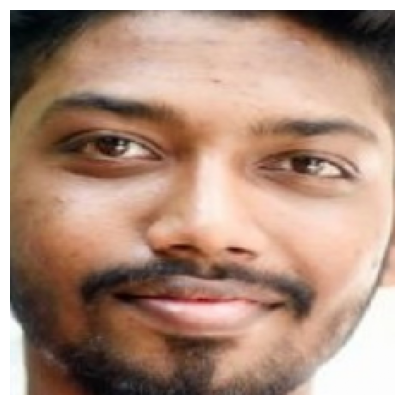

----------------------
Index: 83
Actual:  Malay
Predicted:  Malay


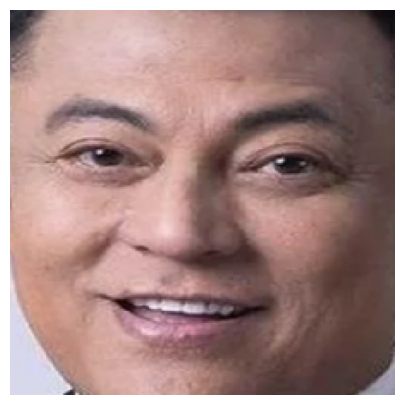

----------------------
Index: 228
Actual:  Chinese
Predicted:  Chinese


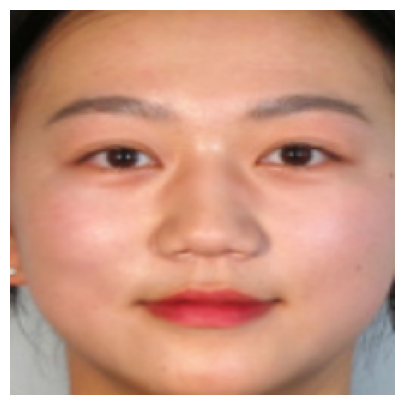

----------------------
Index: 25
Actual:  Malay
Predicted:  Indian


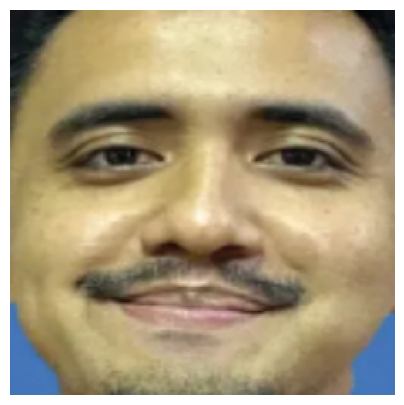

----------------------
Index: 231
Actual:  Chinese
Predicted:  Chinese


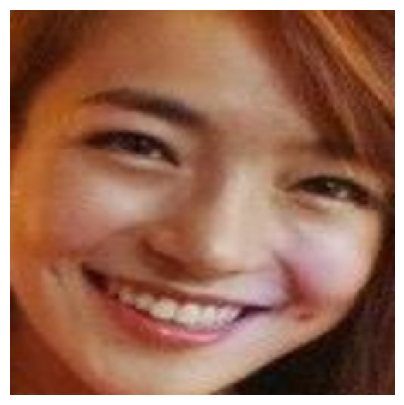

----------------------
Index: 267
Actual:  Malay
Predicted:  Malay


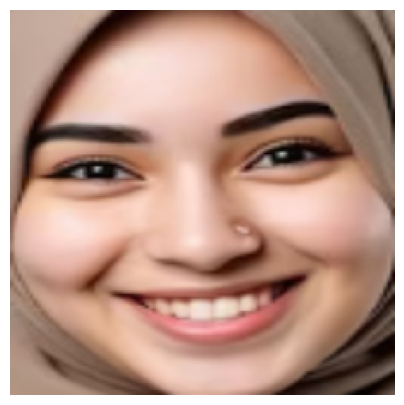

----------------------
Index: 149
Actual:  Chinese
Predicted:  Chinese


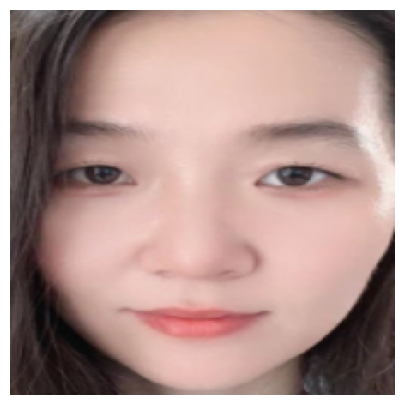

----------------------
Index: 157
Actual:  Indian
Predicted:  Indian


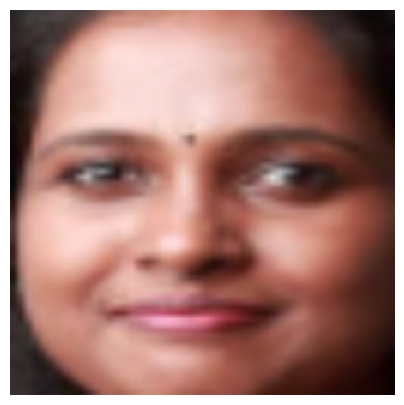

----------------------
Index: 32
Actual:  Indian
Predicted:  Indian


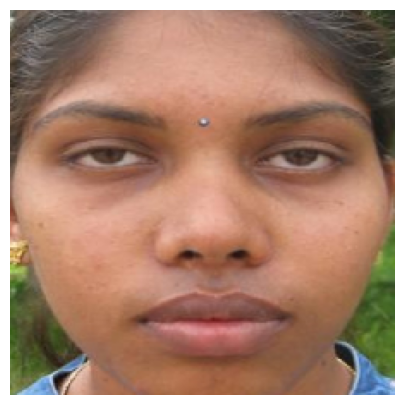

----------------------
Index: 88
Actual:  Malay
Predicted:  Indian


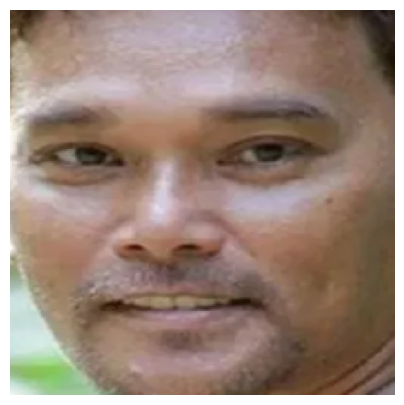

----------------------
Index: 31
Actual:  Malay
Predicted:  Malay


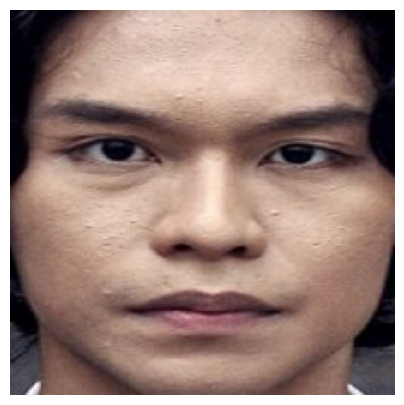

----------------------
Index: 120
Actual:  Indian
Predicted:  Indian


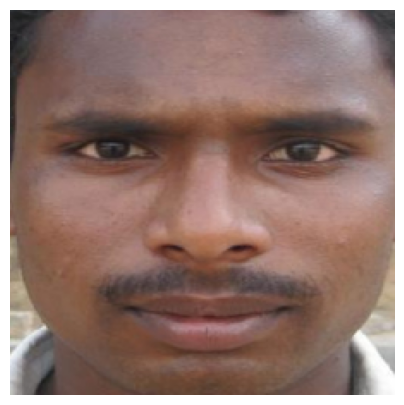

----------------------
Index: 42
Actual:  Malay
Predicted:  Malay


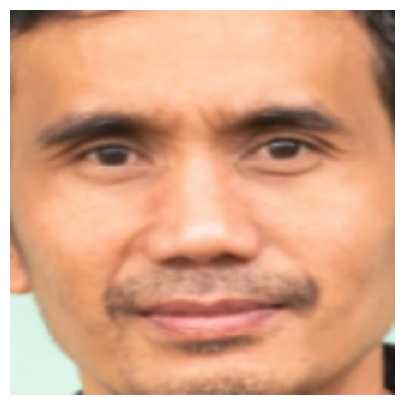

----------------------
Index: 111
Actual:  Indian
Predicted:  Indian


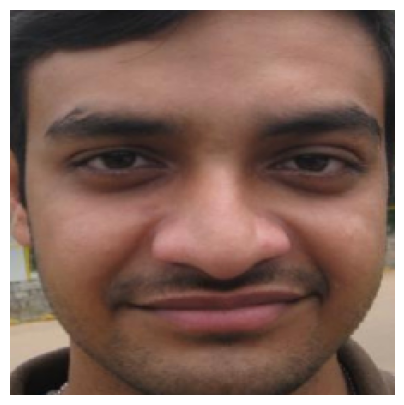

----------------------
Index: 129
Actual:  Malay
Predicted:  Chinese


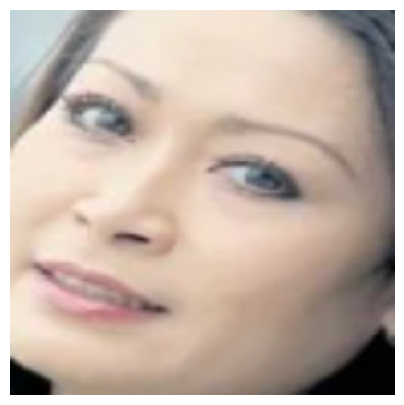

----------------------
Index: 45
Actual:  Malay
Predicted:  Chinese


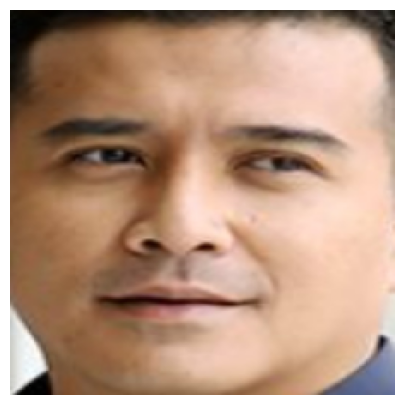

----------------------
Index: 96
Actual:  Malay
Predicted:  Malay


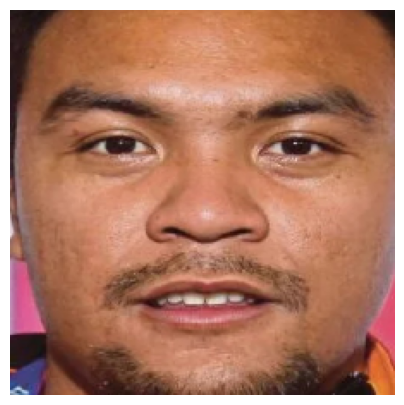

----------------------
Index: 235
Actual:  Chinese
Predicted:  Chinese


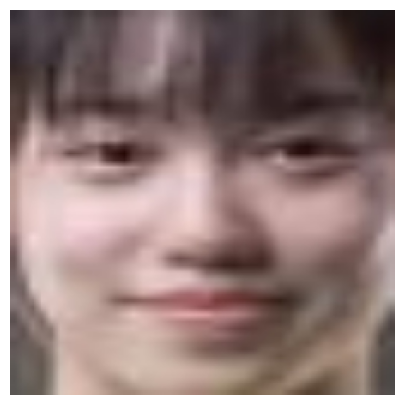

----------------------
Index: 110
Actual:  Malay
Predicted:  Malay


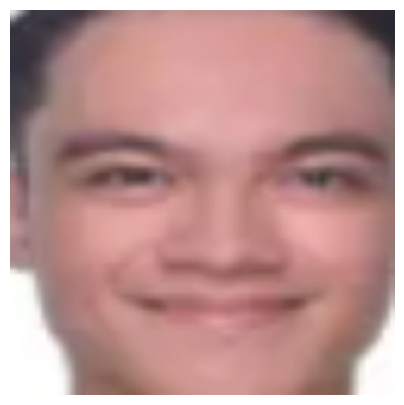

----------------------
Index: 138
Actual:  Indian
Predicted:  Indian


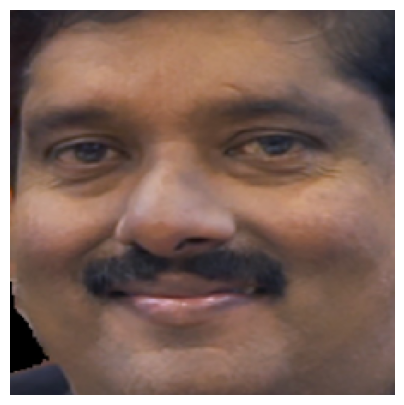

----------------------
Index: 103
Actual:  Indian
Predicted:  Indian


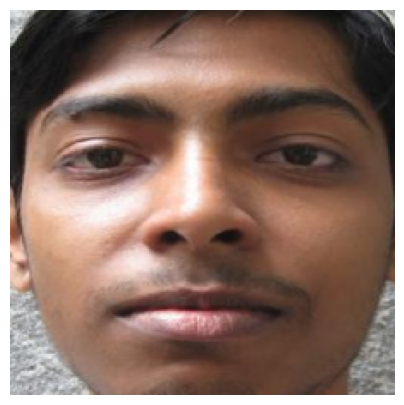

----------------------
Index: 2
Actual:  Chinese
Predicted:  Chinese


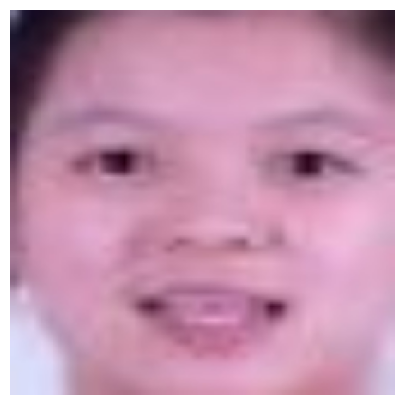

----------------------
Index: 180
Actual:  Chinese
Predicted:  Chinese


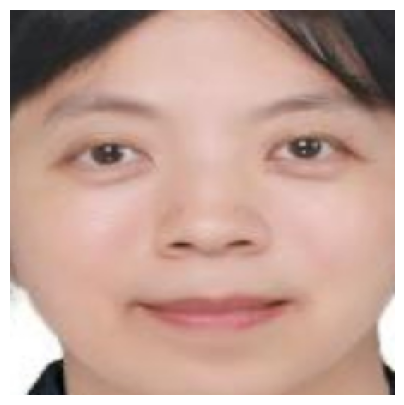

----------------------
Index: 126
Actual:  Chinese
Predicted:  Chinese


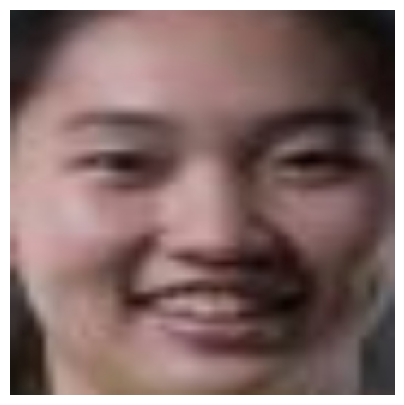

----------------------
Index: 240
Actual:  Malay
Predicted:  Indian


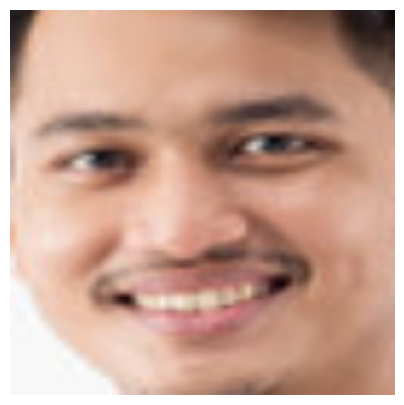

----------------------
Index: 258
Actual:  Malay
Predicted:  Malay


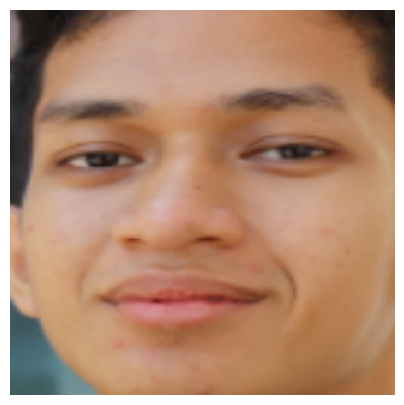

----------------------
Index: 17
Actual:  Malay
Predicted:  Malay


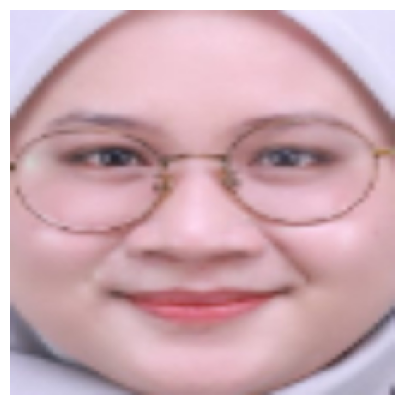

----------------------
Index: 274
Actual:  Indian
Predicted:  Indian


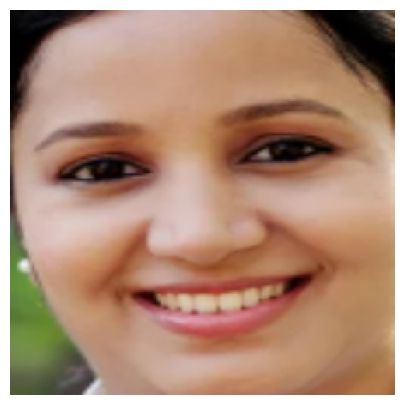

----------------------
Index: 49
Actual:  Malay
Predicted:  Malay


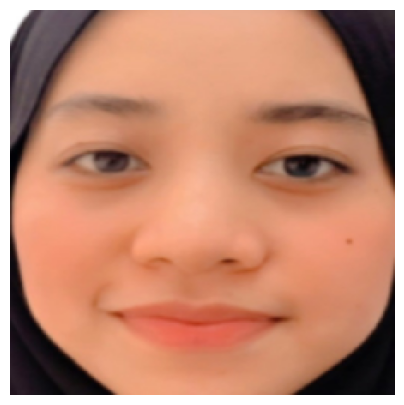

----------------------


In [10]:
## 10. Sample Predictions
best_model_name = results_summary.loc[results_summary['Test Loss'].idxmin(), 'Model']
best_model = {'Baseline': baseline_model, 'Fine-Tuned 1': ft1_model, 'Fine-Tuned 2': ft2_model}[best_model_name]

predictions = best_model.predict(test_features, verbose=0)
random_indices = random.sample(range(predictions.shape[0]), 30)
prediction_classes = []
actual_classes = []

print(f"\nSample Predictions from {best_model_name}:\n")
for i in random_indices:
    prediction = np.argmax(predictions[i])
    prediction_classes.append(races[prediction])
    actual = np.argmax(test_target.values[i])
    actual_classes.append(races[actual])

    print(f"Index: {i}")
    print("Actual: ", races[actual])
    print("Predicted: ", races[prediction])

    img = (test_df.iloc[i]['pixels'].reshape(224, 224, 3)) / 255.0
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    print("----------------------")